In [1]:
import pandas as pd
from pathlib import Path

FINAL_DATASET_PATH = Path('dataset/data/final_dataset_new.csv')
df_check = pd.read_csv(FINAL_DATASET_PATH)

turnover_cols = ['turnover_c5', 'turnover_c10', 'turnover_c20', 'turnover_m1', 'turnover_m3']

has_any = df_check[turnover_cols].notna().any(axis=1)
df_with_turnover = df_check[has_any].copy()

# exclude rows where every non-null value is -1 (unmerged PRs)
all_neg1 = df_with_turnover[turnover_cols].apply(
    lambda row: all(str(v).strip() == '-1' for v in row if pd.notna(v)), axis=1
)
df_with_turnover = df_with_turnover[~all_neg1]

print(f'Rows with >= 1 real turnover value: {len(df_with_turnover):,} / {len(df_check):,}')
print(f"  Agent rows:    {(df_with_turnover['group'] == 'agent').sum():,}")
print(f"  Developer rows: {(df_with_turnover['group'] == 'human').sum():,}")
print()
print(df_with_turnover[turnover_cols].to_string())


Rows with >= 1 real turnover value: 3,421 / 13,809
  Agent rows:    1,424
  Developer rows: 1,997

                                                turnover_c5                                          turnover_c10                                          turnover_c20                                           turnover_m1                                           turnover_m3
0         ('c5fcc5c284533a73c692c7bdb677c8c0f2e4076c', 0.0)     ('da4597794b35c7ad6401ca45788dfa12a55efe73', 0.0)     ('3750823a0ba6f48030b7794099e5ddc65e9685a2', 0.0)                                                   NaN                                                   NaN
1         ('c5fcc5c284533a73c692c7bdb677c8c0f2e4076c', 0.0)     ('da4597794b35c7ad6401ca45788dfa12a55efe73', 0.0)     ('3750823a0ba6f48030b7794099e5ddc65e9685a2', 0.0)                                                   NaN                                                   NaN
2         ('c5fcc5c284533a73c692c7bdb677c8c0f2e4076c', 0.0)     ('da45977

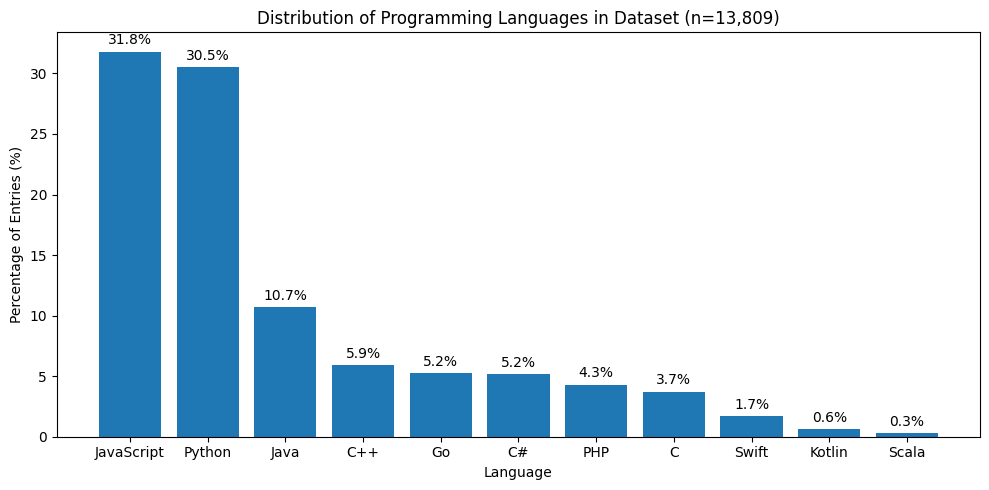

Total functions: 13,809

            count  percent
language                  
JavaScript   4392    31.81
Python       4211    30.49
Java         1481    10.72
C++           814     5.89
Go            723     5.24
C#            712     5.16
PHP           595     4.31
C             515     3.73
Swift         236     1.71
Kotlin         84     0.61
Scala          46     0.33


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

FINAL_DATASET_PATH = 'dataset/data/final_dataset_new.csv'
df = pd.read_csv(FINAL_DATASET_PATH)

ext_to_lang = {
    'py': 'Python', 'js': 'JavaScript', 'jsx': 'JavaScript',
    'java': 'Java', 'cs': 'C#', 'go': 'Go',
    'cpp': 'C++', 'cc': 'C++', 'hpp': 'C++',
    'c': 'C', 'h': 'C',
    'php': 'PHP', 'swift': 'Swift', 'kt': 'Kotlin', 'scala': 'Scala',
}

df['language'] = df['file_path'].str.rsplit('.', n=1).str[-1].map(ext_to_lang).fillna('Other')

lang_counts = df['language'].value_counts()
lang_pct = lang_counts / lang_counts.sum() * 100
total = lang_counts.sum()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(lang_pct.index, lang_pct.values)
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_title(f'Distribution of Programming Languages in Dataset (n={total:,})')
ax.set_xlabel('Language')
ax.set_ylabel('Percentage of Entries (%)')
plt.tight_layout()
plt.show()

print(f'Total functions: {total:,}')
print()
print(pd.DataFrame({'count': lang_counts, 'percent': lang_pct.round(2)}).to_string())


In [15]:
import pandas as pd

FINAL_DATASET_PATH = 'dataset/data/final_dataset_new.csv'
df = pd.read_csv(FINAL_DATASET_PATH)

human_df = df[df['group'] == 'human']
agent_df = df[df['group'] == 'agent']

n_human_funcs = len(human_df)
n_agent_funcs = len(agent_df)

human_per_repo = human_df.groupby('repo').size()
agent_per_repo = agent_df.groupby('repo').size()

n_human_repos = len(human_per_repo)
n_agent_repos = len(agent_per_repo)

human_mean = human_per_repo.mean()
human_median = human_per_repo.median()
agent_mean = agent_per_repo.mean()
agent_median = agent_per_repo.median()

print(
    f"In total, we analyze {n_human_funcs:,} developer-authored functions and "
    f"{n_agent_funcs:,} agent-authored functions across {n_human_repos:,} developer "
    f"and {n_agent_repos:,} agent-based repositories. We analyzed a mean of {human_mean:.1f} "
    f"and a median of {human_median:.1f} functions per developer repository, while analyzing "
    f"a mean of {agent_mean:.1f} and a median of {agent_median:.1f} functions per agent repository."
)


In total, we analyze 6,834 developer-authored functions and 6,975 agent-authored functions across 252 developer and 260 agent-based repositories. We analyzed a mean of 27.1 and a median of 10.0 functions per developer repository, while analyzing a mean of 26.8 and a median of 9.0 functions per agent repository.
